# Phase 1 — Data Exploration
Goal: Deeply understand the dataset before making any modeling decisions. Every architectural choice in later phases will be justified by what we find here.


In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## Step 1 — Load the raw JSON files

In [2]:
data_dir = "../data/raw"
train_files = glob.glob(os.path.join(data_dir, "train", "*.json"))
val_files = glob.glob(os.path.join(data_dir, "test", "*.json"))

def load_data(files):
    dataset = []
    for f in files:
        with open(f, 'r', encoding='utf-8', errors='replace') as file:
            data = json.load(file)
            for intent, examples in data.items():
                for example in examples:
                    text = "".join([chunk["text"] for chunk in example["data"]])
                    dataset.append({"text": text.strip(), "intent": intent})
    return pd.DataFrame(dataset)

df_train = load_data(train_files)
df_val = load_data(val_files)

print(f"Loaded {len(df_train)} training examples and {len(df_val)} validation examples.")


Loaded 13784 training examples and 700 validation examples.


## Step 2 — Class distribution analysis

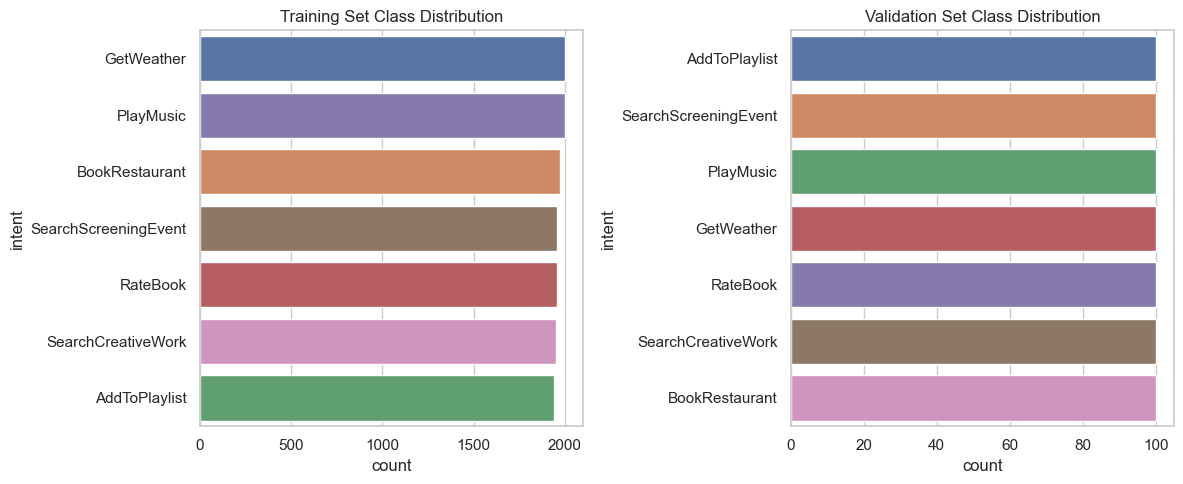

In [3]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(y='intent', data=df_train, order=df_train['intent'].value_counts().index, hue='intent', legend=False)
plt.title('Training Set Class Distribution')

plt.subplot(1, 2, 2)
sns.countplot(y='intent', data=df_val, order=df_val['intent'].value_counts().index, hue='intent', legend=False)
plt.title('Validation Set Class Distribution')
plt.tight_layout()
plt.show()


## Step 3 — Sentence length analysis

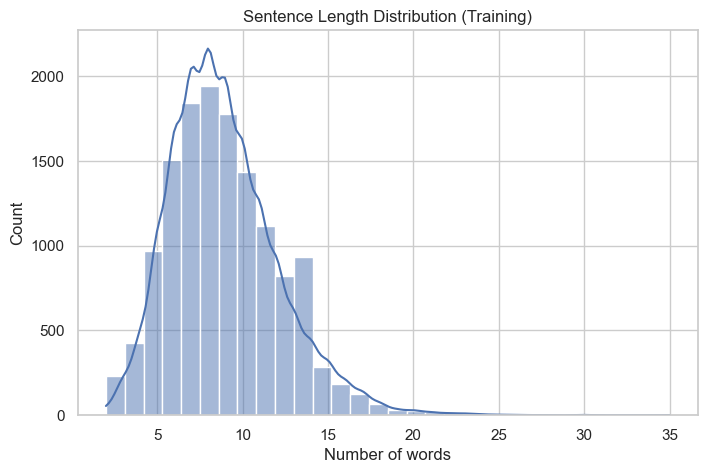

Sentence Length Stats (Train):
Min: 2
Max: 35
Mean: 8.90
Median: 8.0
95th percentile: 15.0


In [4]:
import re

def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

df_train['tokens'] = df_train['text'].apply(tokenize)
df_train['length'] = df_train['tokens'].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(df_train['length'], bins=30, kde=True)
plt.title('Sentence Length Distribution (Training)')
plt.xlabel('Number of words')
plt.show()

print("Sentence Length Stats (Train):")
print(f"Min: {df_train['length'].min()}")
print(f"Max: {df_train['length'].max()}")
print(f"Mean: {df_train['length'].mean():.2f}")
print(f"Median: {df_train['length'].median()}")
print(f"95th percentile: {np.percentile(df_train['length'], 95)}")


## Step 4 — Vocabulary analysis

Total unique words in training set: 11705


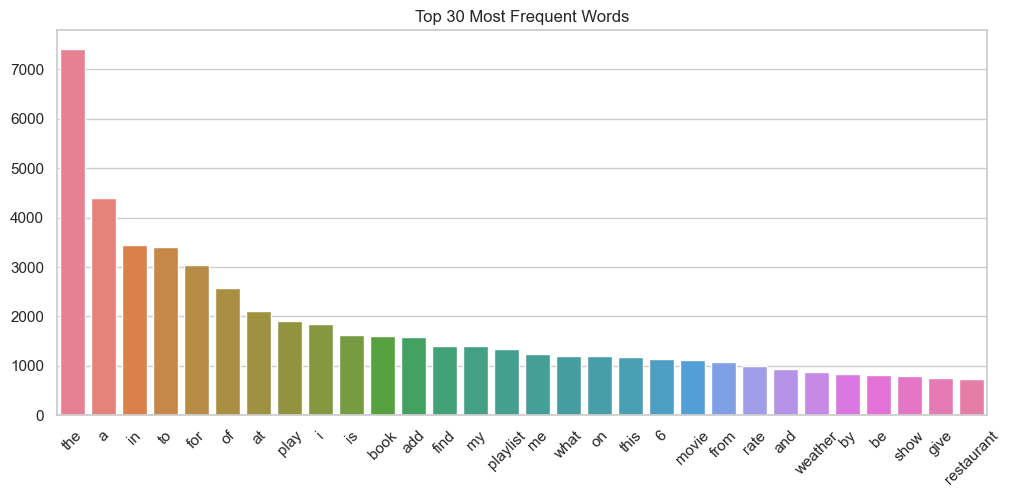

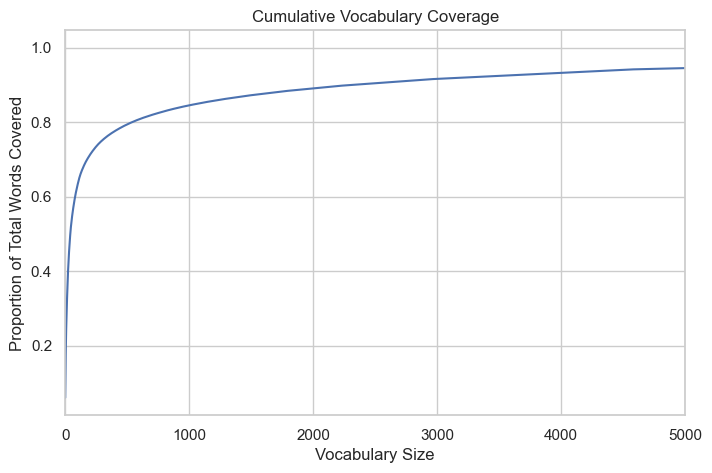

In [5]:
all_words = [word for tokens in df_train['tokens'] for word in tokens]
word_counts = Counter(all_words)

print(f"Total unique words in training set: {len(word_counts)}")

common_words = word_counts.most_common(30)
words, counts = zip(*common_words)
plt.figure(figsize=(12, 5))
sns.barplot(x=list(words), y=list(counts), hue=list(words), legend=False)
plt.xticks(rotation=45)
plt.title('Top 30 Most Frequent Words')
plt.show()

freqs = list(word_counts.values())
freqs.sort(reverse=True)
cumulative = np.cumsum(freqs) / np.sum(freqs)

plt.figure(figsize=(8, 5))
plt.plot(cumulative)
plt.title('Cumulative Vocabulary Coverage')
plt.xlabel('Vocabulary Size')
plt.ylabel('Proportion of Total Words Covered')
plt.xlim(0, 5000)
plt.grid(True)
plt.show()


## Step 5 — Sample inspection

In [6]:
print("--- Sample Inspection ---")
for intent in df_train['intent'].unique():
    print(f"\nIntent: {intent}")
    samples = df_train[df_train['intent'] == intent]['text'].sample(5, random_state=42).tolist()
    for s in samples:
        print(f"  - {s}")


--- Sample Inspection ---

Intent: GetWeather
  - what is the temperate in Uzbekistan
  - Is it forecast to be chilly here on july 14?
  - Is there a lot of sun in Qatar?
  - Will it be hot here at 22 o'clock?
  - Is it going to be cold once I get within walking distance of my home in New Caledonia?

Intent: BookRestaurant
  - book in Bolivia a brasserie for tourte food
  - Book the nearby Meriton Grand Hotel Tallinn in Missouri.
  - book a table for me and savannah in Lauderdale Lakes
  - I'd like to eat at a pub in Arkport
  - Book a table at a diner which serves thousand island dressing in Ivory Coast.

Intent: AddToPlaylist
  - this tune should go on my coffee table jazz playlist
  - Add See Me Now to my enamorándose playlist
  - Add this tune to cristina's endorphin rush playlist
  - Add a song to my playlist Independent Music Monday
  - add this album to the playlist called dishwashing

Intent: RateBook
  - The Night Lamp was ok at best, two stars out of 6 possible.
  - Rate the 